In [15]:
import pandas as pd
import pymc as pm
import japanize_matplotlib
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import numpy as np
import arviz as az

In [2]:
df = pd.read_csv("../data/telco_churn_survival.csv")
df

,customerID,tenure,Churn,Contract,MonthlyCharges,gender,SeniorCitizen,event
0,7590-VHVEG,1,No,Month-to-month,29.85,Female,0,0
1,5575-GNVDE,34,No,One year,56.95,Male,0,0
2,3668-QPYBK,2,Yes,Month-to-month,53.85,Male,0,1
3,7795-CFOCW,45,No,One year,42.30,Male,0,0
4,9237-HQITU,2,Yes,Month-to-month,70.70,Female,0,1
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,No,One year,84.80,Male,0,0
7039,2234-XADUH,72,No,One year,103.20,Female,0,0
7040,4801-JZAZL,11,No,Month-to-month,29.60,Female,0,0
7041,8361-LTMKD,4,Yes,Month-to-month,74.40,Male,1,1


count    1869.000000
mean       17.979133
std        19.531123
min         1.000000
25%         2.000000
50%        10.000000
75%        29.000000
max        72.000000
Name: tenure, dtype: float64
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


<Axes: >

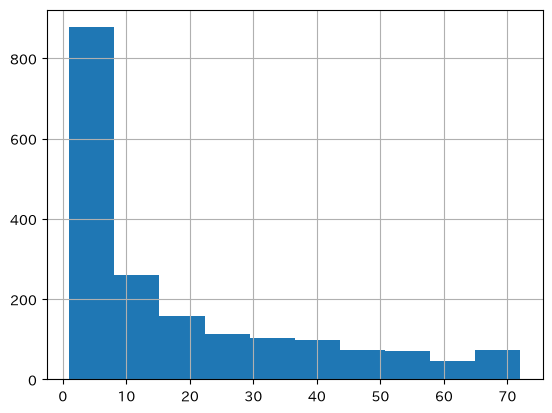

In [20]:
df_is_quit = df[df["Churn"]=="Yes"]
print(df_is_quit["tenure"].describe())
print(df["tenure"].describe())
df_is_quit["tenure"].hist()

In [4]:
t_obs = df["tenure"].values.astype(float)
t_obs_e1 = df_is_quit["tenure"].values.astype(float)
event_obs = df["event"].values.astype(float)
event_obs_e1 = df_is_quit["event"].values.astype(float)
n = len(df)

In [5]:
with pm.Model() as exponential_model_v0:
    lam = pm.Gamma("lam", alpha=50, beta= 50/0.056)

    log_lik = event_obs * pt.log(lam) - lam * t_obs
    pm.Potential("loglike", pt.sum(log_lik))

In [6]:
g_v0 = pm.model_to_graphviz(exponential_model_v0)

In [7]:
with exponential_model_v0:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

/tmp/ipykernel_22990/1758861205.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [lam]


lam: 平均= 0.05600997705069501 範囲=[ 0.02917129457735773 , 0.07806587087068059 ]
シミュレートされたtenureの中央値: 12.24232855336525
実データのtenureの中央値: 29.0


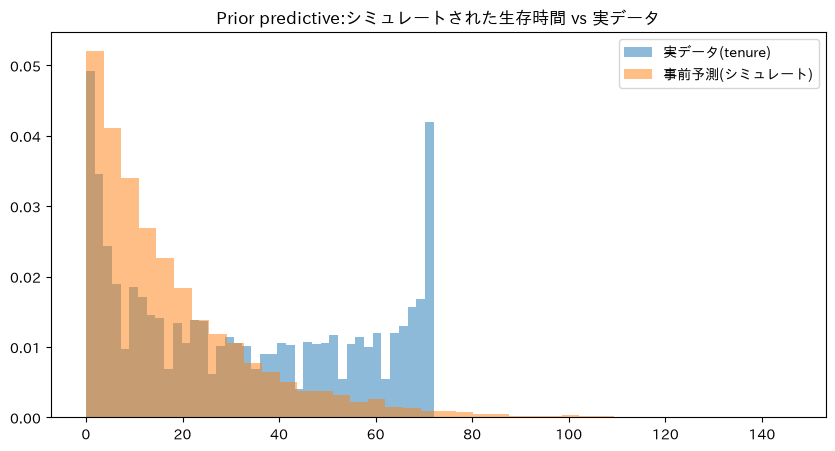

In [8]:
lam_prior = prior.prior["lam"].values.flatten()

np.random.seed(42)
simulated_tenure = np.random.exponential(scale=1/lam_prior.mean(), size=n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(t_obs, bins=40, density=True, alpha=0.5, label="実データ(tenure)")
ax.hist(simulated_tenure, bins=40, density=True, alpha=0.5, label="事前予測(シミュレート)")
ax.legend()
ax.set_title("Prior predictive:シミュレートされた生存時間 vs 実データ")
plt.savefig("../img/survival_prior_check_v0.png", dpi=100)

print("lam: 平均=", lam_prior.mean(), "範囲=[", lam_prior.min(), ",", lam_prior.max(),"]")
print("シミュレートされたtenureの中央値:", np.median(simulated_tenure))
print("実データのtenureの中央値:", np.median(t_obs))

In [9]:
#Churn="Yes"のみ
with pm.Model() as exponential_model_v1:
    lam = pm.Gamma("lam", alpha=50, beta= 50/0.056)

    log_lik = event_obs_e1 * pt.log(lam) - lam * t_obs_e1
    pm.Potential("loglike", pt.sum(log_lik))

In [10]:
with exponential_model_v1:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

/tmp/ipykernel_22990/4149306302.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [lam]


lam: 平均= 0.05600997705069501 範囲=[ 0.02917129457735773 , 0.07806587087068059 ]
シミュレートされたtenureの中央値: 12.596094694678067
実データのtenureの中央値: 10.0


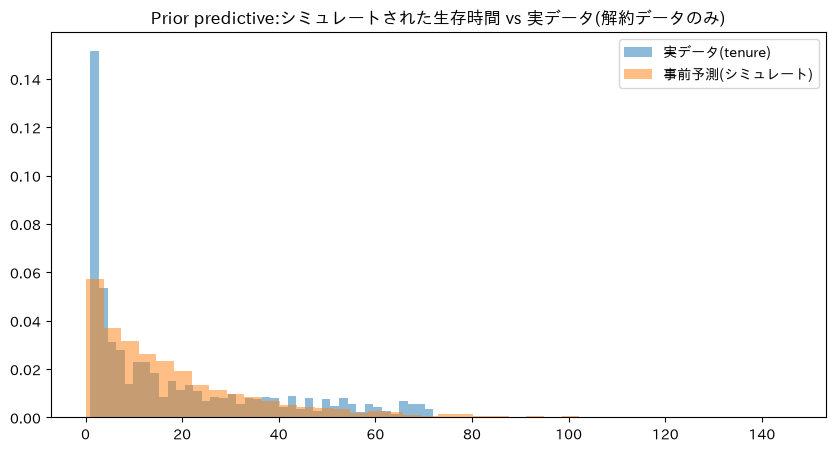

In [14]:
lam_prior = prior.prior["lam"].values.flatten()

np.random.seed(42)
simulated_tenure = np.random.exponential(scale=1/lam_prior.mean(), size=len(t_obs_e1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(t_obs_e1, bins=40, density=True, alpha=0.5, label="実データ(tenure)")
ax.hist(simulated_tenure, bins=40, density=True, alpha=0.5, label="事前予測(シミュレート)")
ax.legend()
ax.set_title("Prior predictive:シミュレートされた生存時間 vs 実データ(解約データのみ)")
plt.savefig("../img/survival_prior_check_v1.png", dpi=100)

print("lam: 平均=", lam_prior.mean(), "範囲=[", lam_prior.min(), ",", lam_prior.max(),"]")
print("シミュレートされたtenureの中央値:", np.median(simulated_tenure))
print("実データのtenureの中央値:", np.median(t_obs_e1))

In [16]:
with exponential_model_v0:
 idata = pm.sample(draws=2000, tune=2000, chains=4, target_accept=0.9, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=["lam"])

NUTS[numpyro]: [lam]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%|                                     | 0/4000 [00:00<?, ?it/s]

  0%|                                                   | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                     | 0/4000 [00:00<?, ?it/s]


  0%|                                                   | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                  | 0/4000 [00:01<?, ?it/s]

Running chain 2:   0%|                                  | 0/4000 [00:01<?, ?it/s]


Running chain 3:   0%|                                  | 0/4000 [00:01<?, ?it/s]

Running chain 1:  30%|██████              | 1200/4000 [00:01<00:00, 11365.73it/s]


Running chain 3:  30%|██████              | 1200/4000 [00:01<00:00, 10634.98it/s]

Running chain 0:  65%|█████████████       | 2600/4000 [00:01<00:00, 11779.50it/s]


Running chain 3:  65%|███████████

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
lam,0.008381,0.000194,0.0081,0.0087,2346,2295,1.00,4e-06,2.8e-06


In [17]:
#カプランマイヤー曲線
def kaplan_meier(t_obs, event_obs):
    order = np.argsort(t_obs)
    t_sorted = t_obs[order]
    e_sorted = event_obs[order]
    unique_times = np.unique(t_sorted[e_sorted == 1])

    survival = 1.0
    km_times= [0]
    km_surv = [1.0]
    n_at_risk = len(t_obs)

    for t in unique_times:
        n_event = np.sum((t_sorted == t) & (e_sorted == 1))
        n_at_risk = np.sum(t_sorted >= t)
        survival *= (1 - n_event / n_at_risk)
        km_times.append(t)
        km_surv.append(survival)

    return np.array(km_times), np.array(km_surv)

km_t, km_s = kaplan_meier(t_obs, event_obs)
    
    

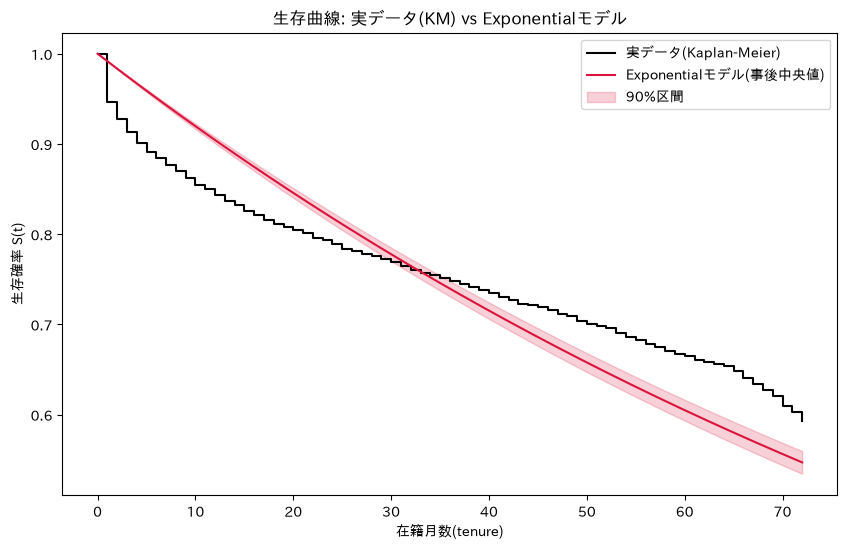

In [19]:
lam_post = idata.posterior["lam"].values.flatten()
t_range = np.linspace(0, 72, 200)

S_samples = np.exp(-np.outer(lam_post, t_range))
S_median = np.median(S_samples, axis=0)
S_lower = np.percentile(S_samples, 5, axis=0)
S_upper = np.percentile(S_samples, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.step(km_t, km_s, where="post", color="black", label="実データ(Kaplan-Meier)")
ax.plot(t_range, S_median, color="crimson", label="Exponentialモデル(事後中央値)")
ax.fill_between(t_range, S_lower, S_upper, color="crimson", alpha=0.2, label="90%区間")
ax.set_xlabel("在籍月数(tenure)")
ax.set_ylabel("生存確率 S(t)")
ax.legend()
ax.set_title("生存曲線: 実データ(KM) vs Exponentialモデル")
plt.savefig("../img/survival_curve_comparison.png", dpi=100)
